In [1]:

# Deneyi farklı kategoriler için tekrarlamak istediğimizde sadece burayı değiştireceğiz.
CATEGORY =  "hazelnut"         # categories = "carpet" , "hazelnut" , "bottle"
# -----------------
print(f"Selected Category:{CATEGORY}")

Selected Category:hazelnut


In [2]:
import time
from google.colab import drive
import os
import torch


drive.mount('/content/drive')
print("Google Drive mounted successfully.")


BASE_DIR = '/content/drive/MyDrive/anomaly_detection_project/dataset/'

PROJECT_DIR = f'/content/drive/MyDrive/anomaly_detection_project/autoencoder_manual_{CATEGORY}/'
os.makedirs(PROJECT_DIR, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project directory is set to: {PROJECT_DIR}")
print(f"Device is set to: {device}")



Mounted at /content/drive
Google Drive mounted successfully.
Project directory is set to: /content/drive/MyDrive/anomaly_detection_project/autoencoder_manual_hazelnut/
Device is set to: cuda


In [3]:

start_time = time.time()
print("\nTimer started. All subsequent computation time will be measured.")


Timer started. All subsequent computation time will be measured.


In [4]:
import torch
from torch import nn


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()


        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True)
        )


        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        x = self.decoder(x)
        return x


autoencoder_model = Autoencoder().to(device)

print("Autoencoder model architecture defined successfully.")
print("Model created and moved to the 'cuda' device.")


Autoencoder model architecture defined successfully.
Model created and moved to the 'cuda' device.


In [5]:
from PIL import Image
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch



class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, split='train', image_size=(256, 256)):
        self.root_dir = root_dir
        self.category = category
        self.split = split
        self.image_paths = []
        self.labels = []

        self.transform = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])
        self._setup_paths()

    def _setup_paths(self):
        if self.split == 'train':
            class_dir = os.path.join(self.root_dir, self.category, 'train', 'good')
            self.image_paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
            self.labels = [0] * len(self.image_paths)
        else: # test
            test_dir = os.path.join(self.root_dir, self.category, 'test')
            class_dirs = sorted([f for f in glob.glob(os.path.join(test_dir, '*')) if os.path.isdir(f)])
            for class_dir in class_dirs:
                class_name = os.path.basename(class_dir)
                paths = sorted(glob.glob(os.path.join(class_dir, '*.png')))
                self.image_paths.extend(paths)
                self.labels.extend([0 if class_name == 'good' else 1] * len(paths))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform(image)
        return {"image": image_tensor, "label": label}

full_train_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split="train")


train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))


train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

print(f"DataLoaders for Training & Validation are ready for '{CATEGORY}'.")
print(f"Training subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

DataLoaders for Training & Validation are ready for 'hazelnut'.
Training subset size: 312
Validation subset size: 79


In [6]:
from torch import nn



class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

autoencoder_model = Autoencoder().to(device)
print("Autoencoder model architecture is ready.")

loss_function = nn.MSELoss()
print("Loss Function: Mean Squared Error   is set.")

optimizer = torch.optim.Adam(autoencoder_model.parameters(), lr=1e-3, weight_decay=1e-5)
print("Optimizer: Adam is set.")

print("\nAll components are ready for the new, advanced training loop.")

Autoencoder model architecture is ready.
Loss Function: Mean Squared Error   is set.
Optimizer: Adam is set.

All components are ready for the new, advanced training loop.


In [7]:
from tqdm import tqdm
import numpy as np
import copy




num_epochs = 200

from tqdm import tqdm
import numpy as np
import copy




num_epochs = 200
patience = 10
min_delta = 0.0001


best_loss = np.inf
epochs_no_improve = 0
best_model_weights = None

for epoch in range(num_epochs):

    autoencoder_model.train()
    train_loss = 0.0
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs} [Training]"):


        images = batch["image"].to(device)

        optimizer.zero_grad()
        outputs = autoencoder_model(images)
        loss = loss_function(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dataloader)


    autoencoder_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:


            images = batch["image"].to(device)

            outputs = autoencoder_model(images)
            loss = loss_function(outputs, images)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_dataloader)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_train_loss:.6f}, Validation Loss: {avg_val_loss:.6f}")


    if avg_val_loss < best_loss - min_delta:
        best_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(autoencoder_model.state_dict())
        print("Validation loss decreased. Saving model weights.")
    else:
        epochs_no_improve += 1
        print(f"Validation loss did not improve for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {patience} epochs with no improvement.")
        break

if best_model_weights:
    print("\nLoading best model weights found during training.")
    autoencoder_model.load_state_dict(best_model_weights)

print("\nTraining complete.")

Epoch 1/200 [Training]: 100%|██████████| 10/10 [00:44<00:00,  4.49s/it]


Epoch [1/200], Training Loss: 0.085236, Validation Loss: 0.047282
Validation loss decreased. Saving model weights.


Epoch 2/200 [Training]: 100%|██████████| 10/10 [00:09<00:00,  1.09it/s]


Epoch [2/200], Training Loss: 0.034946, Validation Loss: 0.024121
Validation loss decreased. Saving model weights.


Epoch 3/200 [Training]: 100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


...

Epoch [30/200], Training Loss: 0.000433, Validation Loss: 0.000395
Validation loss did not improve for 8 epoch(s).


Epoch 31/200 [Training]: 100%|██████████| 10/10 [00:09<00:00,  1.10it/s]


Epoch [31/200], Training Loss: 0.000410, Validation Loss: 0.000386
Validation loss did not improve for 9 epoch(s).


Epoch 32/200 [Training]: 100%|██████████| 10/10 [00:09<00:00,  1.09it/s]


Epoch [32/200], Training Loss: 0.000405, Validation Loss: 0.000379
Validation loss did not improve for 10 epoch(s).

Early stopping triggered after 10 epochs with no improvement.

Loading best model weights found during training.

Training complete.


In [8]:


test_dataset = MVTecDataset(root_dir=BASE_DIR, category=CATEGORY, split='test')

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Test DataLoader created for '{CATEGORY}'.")
print(f"Number of test images found: {len(test_dataset)}")

Test DataLoader created for 'hazelnut'.
Number of test images found: 110


In [9]:
from tqdm import tqdm
import torch
from torch import nn



test_scores = []
test_labels = []


loss_function_test = nn.MSELoss(reduction='none')


autoencoder_model.eval()

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc=f"Testing on '{CATEGORY}'"):

        images = batch["image"].to(device)
        labels = batch["label"]

        outputs = autoencoder_model(images)

        loss = loss_function_test(outputs, images)

        image_scores = torch.mean(loss, dim=[1, 2, 3])

        test_scores.append(image_scores.cpu())
        test_labels.append(labels.cpu())

all_scores_ae = torch.cat(test_scores).numpy()
all_labels_ae = torch.cat(test_labels).numpy()

print("\nTesting complete.")
print(f"Anomaly scores calculated for all {len(all_labels_ae)} test images.")

Testing on 'hazelnut': 100%|██████████| 4/4 [00:55<00:00, 13.83s/it]


Testing complete.
Anomaly scores calculated for all 110 test images.


Best Threshold found: 0.0005

Classification Report (at best threshold):
              precision    recall  f1-score   support

      Normal       0.75      0.82      0.79        40
     Anomaly       0.89      0.84      0.87        70

    accuracy                           0.84       110
   macro avg       0.82      0.83      0.83       110
weighted avg       0.84      0.84      0.84       110


Confusion Matrix:


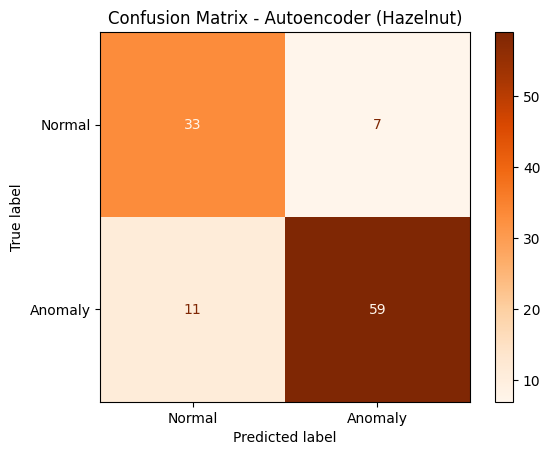

In [10]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(all_labels_ae, all_scores_ae)

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Best Threshold found: {best_thresh:.4f}")

y_pred_ae = (all_scores_ae >= best_thresh).astype(int)

print("\nClassification Report (at best threshold):")
print(classification_report(all_labels_ae, y_pred_ae, target_names=['Normal', 'Anomaly']))

print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_predictions(
    all_labels_ae,
    y_pred_ae,
    display_labels=['Normal', 'Anomaly'],
    cmap=plt.cm.Oranges
)
plt.title(f"Confusion Matrix - Autoencoder ({CATEGORY.capitalize()})")
plt.show()


Calculated AUROC Score for Autoencoder (Hazelnut): 0.8907

ROC Curve:


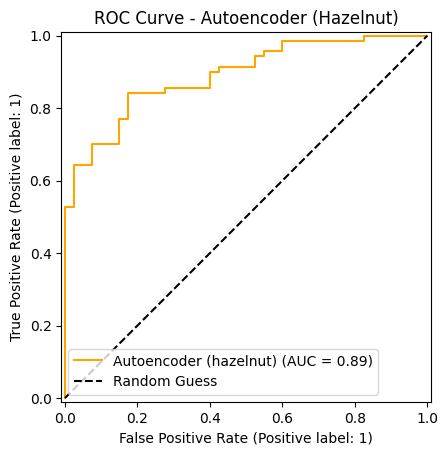

In [11]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt


auroc_score = roc_auc_score(all_labels_ae, all_scores_ae)
print(f"\nCalculated AUROC Score for Autoencoder ({CATEGORY.capitalize()}): {auroc_score:.4f}")

print("\nROC Curve:")
RocCurveDisplay.from_predictions(
    all_labels_ae,
    all_scores_ae,
    name=f"Autoencoder ({CATEGORY})",
    color="orange"
)
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve - Autoencoder ({CATEGORY.capitalize()})")
plt.legend()
plt.show()

In [12]:

end_time = time.time()
elapsed_time = end_time - start_time

print(f"The process took {elapsed_time:.2f} seconds.")
print(f"({elapsed_time / 60:.2f} minutes)")

The process took 491.53 seconds.
(8.19 minutes)
